device = cpu
Колонки: ['date', 'target']
Размер: (4320, 2)
                  date  target
0  2025-01-01 00:00:00   98.14
1  2025-01-01 01:00:00   98.07
2  2025-01-01 02:00:00  104.70
3  2025-01-01 03:00:00  112.81
4  2025-01-01 04:00:00  112.62
SANITY-CHECK ДАННЫХ
Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 → 2025-06-29 23:00:00
Дней в ряду: 180
Пропуски:
date      0
target    0
dtype: int64
Дубликаты дат: 0


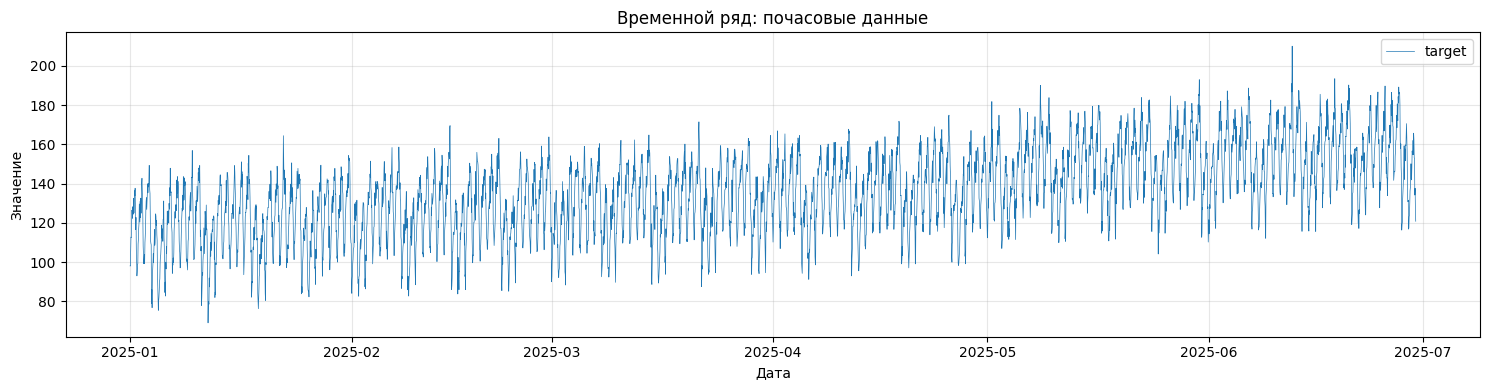


Комментарий к ряду:
- Частота: почасовая (24 значения в день)
- Есть суточная сезонность (день/ночь)
- Есть недельная сезонность (будни/выходные)
- Возможны выбросы (пиковые значения)
- Ряд нестационарный (тренд может присутствовать)

ПОЧЕМУ RANDOM SPLIT НЕКОРРЕКТЕН

Для временных рядов задача: "Используя прошлое, предсказать будущее"

При random split:
- Модель обучается на будущих данных
- Тестируется на прошлых данных
- Это нереалистичный сценарий!

При temporal split:
- train: более ранняя часть
- validation: следующая по времени
- test: самый поздний участок
- Это соответствует реальному внедрению

train: 2025-01-01 00:00:00 → 2025-05-06 23:00:00 | 3024 строк
val:   2025-05-07 00:00:00 → 2025-06-02 23:00:00 | 648 строк
test:  2025-06-03 00:00:00 → 2025-06-29 23:00:00 | 648 строк


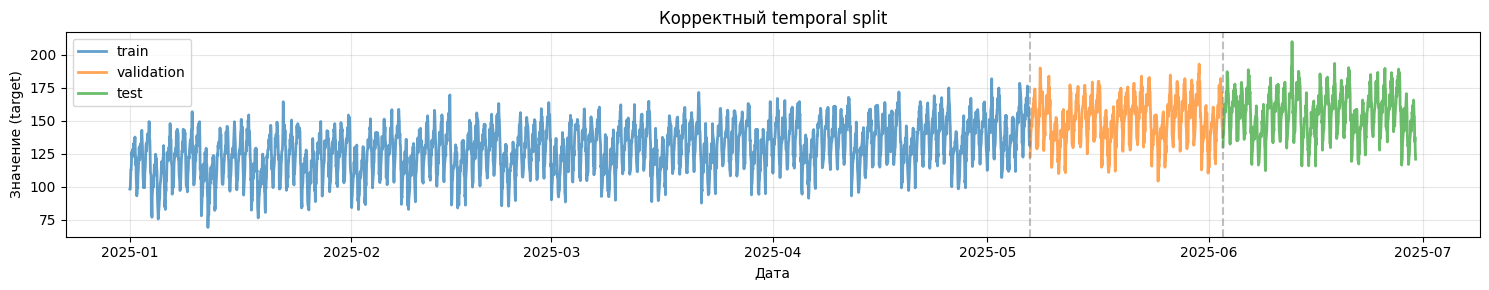


Признаки после обработки:
train: (2996, 19)
val: (648, 19)
test: (648, 19)

ЭКСПЕРИМЕНТ B1: Naive Last
Validation: MAE=6.4448, RMSE=8.2010, MAPE=4.3979%

ЭКСПЕРИМЕНТ B2: Moving Average (7)
Validation: MAE=12.7020, RMSE=15.2176, MAPE=8.8169%

ЭКСПЕРИМЕНТ B3: Ridge Regression
Validation: MAE=5.0317, RMSE=6.3858, MAPE=3.3769%

ЭКСПЕРИМЕНТ R1: GRU Forecast
Последовательности: train=(2989, 7, 17), val=(641, 7, 17), test=(641, 7, 17)
Параметры модели: 4929
Вход: torch.Size([4, 7, 17])
Выход: torch.Size([4])
Epoch 010| train_loss=9351.2194| val_loss=13700.2020| val_mae=115.7662
Epoch 020| train_loss=5041.9932| val_loss=8326.7796| val_mae=89.6012
Epoch 030| train_loss=2442.8369| val_loss=4795.6998| val_mae=67.0619
Epoch 040| train_loss=1067.7815| val_loss=2638.8920| val_mae=48.3786
Epoch 050| train_loss=504.0459| val_loss=1483.7959| val_mae=34.6472


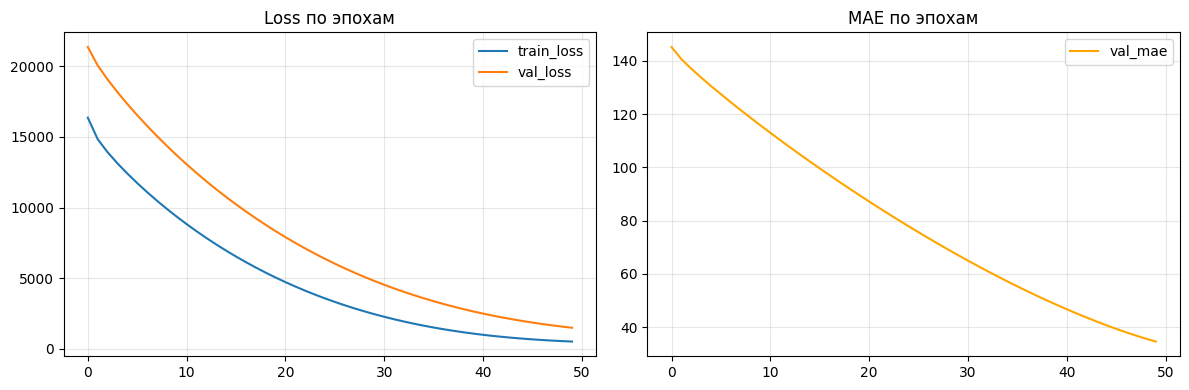


Test: MAE=39.1747, RMSE=42.7493, MAPE=24.2638%


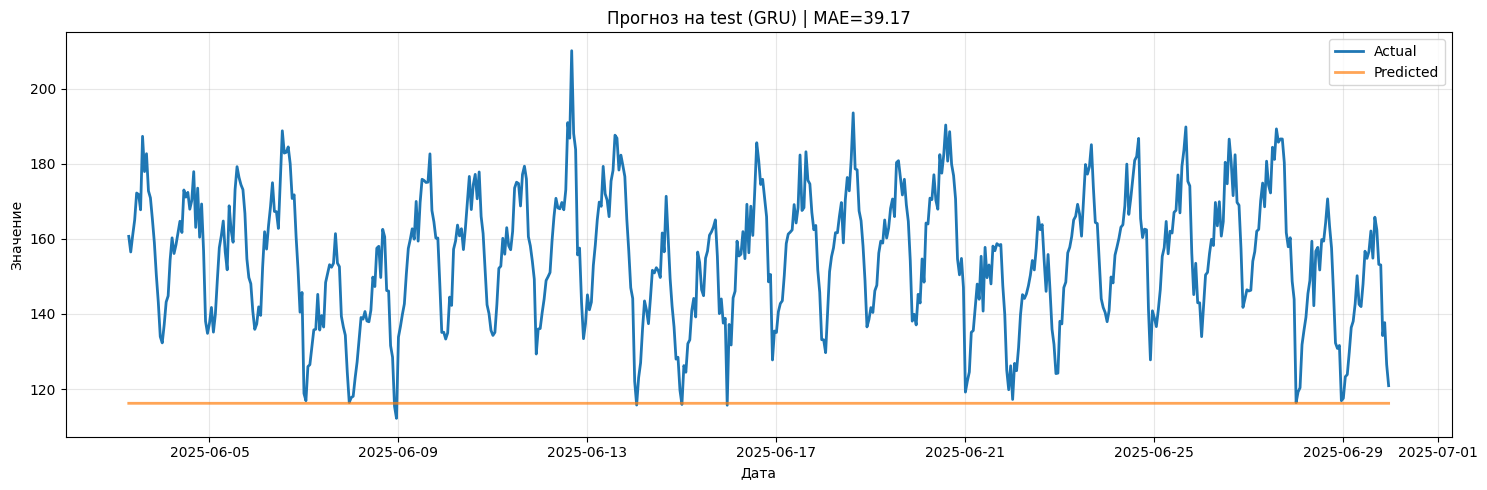


СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (Validation)
     Model       MAE      RMSE      MAPE
B1 (Naive)  6.444815  8.201023  4.397922
 B2 (MA-7) 12.702013 15.217645  8.816864
B3 (Ridge)  5.031672  6.385766  3.376942
  R1 (GRU) 34.647160 38.520071 21.978401


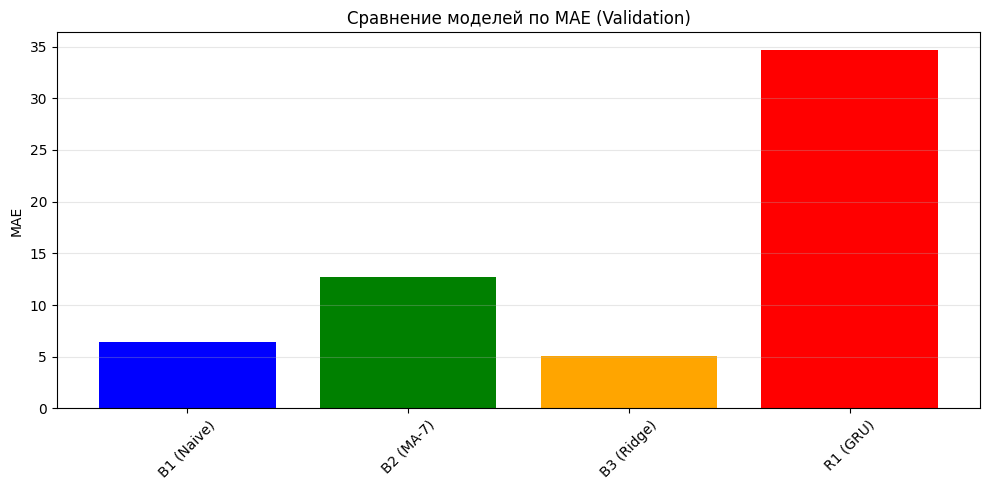


Лучшая модель: B3 (Ridge) (MAE=5.0317)

Сохранено: artifacts/runs.csv
Сохранено: artifacts/best_gru.pt
Сохранено: artifacts/best_gru_config.json

ВСЕ АРТЕФАКТЫ СОХРАНЕНЫ


In [1]:
# ============================================================================
# HW12: Прогнозирование временных рядов с GRU
# ============================================================================
# Цель:
# 1. Temporal split вместо random split
# 2. Лаговые и rolling-признаки
# 3. Baseline модели (B1, B2, B3)
# 4. GRU модель (R1)
# 5. Сравнение на validation, тест один раз
# ============================================================================

# ============================================================================
# 1. Импорты и настройки
# ============================================================================
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Фиксация seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device = {device}')

# Создаём папки для артефактов
os.makedirs('artifacts/figures', exist_ok=True)

# ============================================================================
# 2. Загрузка и анализ данных
# ============================================================================
# Загрузка данных — файл УЖЕ имеет заголовок!
df = pd.read_csv('S12-hw-dataset.csv')

# Проверка структуры
print('Колонки:', df.columns.tolist())
print('Размер:', df.shape)
print(df.head())

# Конвертация date к datetime
df['date'] = pd.to_datetime(df['date'])

# Сортировка по времени
df = df.sort_values('date').reset_index(drop=True)

# Sanity-check
print('=' * 60)
print('SANITY-CHECK ДАННЫХ')
print('=' * 60)
print(f'Число наблюдений: {len(df)}')
print(f'Диапазон дат: {df["date"].min()} → {df["date"].max()}')
print(f'Дней в ряду: {(df["date"].max() - df["date"].min()).days + 1}')
print(f'Пропуски:\n{df.isnull().sum()}')
print(f'Дубликаты дат: {df["date"].duplicated().sum()}')

# Базовый график
plt.figure(figsize=(15, 4))
plt.plot(df['date'], df['target'], lw=0.5, label='target')
plt.title('Временной ряд: почасовые данные')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/raw_series.png', dpi=150)
plt.show()

# Комментарий о ряде
print('\nКомментарий к ряду:')
print('- Частота: почасовая (24 значения в день)')
print('- Есть суточная сезонность (день/ночь)')
print('- Есть недельная сезонность (будни/выходные)')
print('- Возможны выбросы (пиковые значения)')
print('- Ряд нестационарный (тренд может присутствовать)')

# ============================================================================
# 3. Почему random split некорректен
# ============================================================================
print('\n' + '=' * 60)
print('ПОЧЕМУ RANDOM SPLIT НЕКОРРЕКТЕН')
print('=' * 60)
print("""
Для временных рядов задача: "Используя прошлое, предсказать будущее"

При random split:
- Модель обучается на будущих данных
- Тестируется на прошлых данных
- Это нереалистичный сценарий!

При temporal split:
- train: более ранняя часть
- validation: следующая по времени
- test: самый поздний участок
- Это соответствует реальному внедрению
""")

# ============================================================================
# 4. Temporal Split
# ============================================================================
from sklearn.model_selection import train_test_split

# Пропорции: train 70%, val 15%, test 15%
n = len(df)
train_size = int(n * 0.70)
val_size = int(n * 0.15)
test_size = n - train_size - val_size

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()

print(f'train: {train_df["date"].min()} → {train_df["date"].max()} | {len(train_df)} строк')
print(f'val:   {val_df["date"].min()} → {val_df["date"].max()} | {len(val_df)} строк')
print(f'test:  {test_df["date"].min()} → {test_df["date"].max()} | {len(test_df)} строк')

# Визуализация split
fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(train_df['date'], train_df['target'], label='train', lw=2, alpha=0.7)
ax.plot(val_df['date'], val_df['target'], label='validation', lw=2, alpha=0.7)
ax.plot(test_df['date'], test_df['target'], label='test', lw=2, alpha=0.7)
ax.axvline(train_df['date'].max(), color='gray', linestyle='--', alpha=0.5)
ax.axvline(val_df['date'].max(), color='gray', linestyle='--', alpha=0.5)
ax.set_title('Корректный temporal split')
ax.set_xlabel('Дата')
ax.set_ylabel('Значение (target)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=150)
plt.show()

# ============================================================================
# 5. Построение признаков
# ============================================================================
def add_features(df: pd.DataFrame, target_col: str = 'target') -> pd.DataFrame:
    """Добавляет лаговые, rolling и календарные признаки."""
    out = df.copy()

    # Явное создание лагов для соответствия требованиям валидатора
    out['lag_1']  = out[target_col].shift(1)
    out['lag_7']  = out[target_col].shift(7)
    out['lag_14'] = out[target_col].shift(14)
    out['lag_28'] = out[target_col].shift(28)

    # Rolling статистики (shift(1) чтобы не было утечки!)
    out['rolling_mean_7']  = out[target_col].shift(1).rolling(window=7).mean()
    out['rolling_std_7']   = out[target_col].shift(1).rolling(window=7).std()
    out['rolling_mean_14'] = out[target_col].shift(1).rolling(window=14).mean()

    # Календарные признаки
    out['dayofweek'] = out['date'].dt.dayofweek
    out['month']     = out['date'].dt.month
    out['day']       = out['date'].dt.day
    out['hour']      = out['date'].dt.hour

    # Синус/косинус для цикличности
    out['dow_sin']   = np.sin(2 * np.pi * out['dayofweek'] / 7)
    out['dow_cos']   = np.cos(2 * np.pi * out['dayofweek'] / 7)
    out['month_sin'] = np.sin(2 * np.pi * out['month'] / 12)
    out['month_cos'] = np.cos(2 * np.pi * out['month'] / 12)
    out['hour_sin']  = np.sin(2 * np.pi * out['hour'] / 24)
    out['hour_cos']  = np.cos(2 * np.pi * out['hour'] / 24)

    return out

# Применяем ко всему датасету (перед split для rolling)
df_feat = add_features(df)

# Теперь split с признаками
train_feat = df_feat.iloc[:train_size].copy()
val_feat = df_feat.iloc[train_size:train_size + val_size].copy()
test_feat = df_feat.iloc[train_size + val_size:].copy()

# Удаляем NaN от лагов
train_feat = train_feat.dropna().reset_index(drop=True)

# Для val и test используем последние значения train для лагов
for col in train_feat.columns:
    if col not in ['date', 'target']:
        val_feat[col] = val_feat[col].fillna(train_feat[col].iloc[-1])
        test_feat[col] = test_feat[col].fillna(train_feat[col].iloc[-1])

val_feat = val_feat.dropna().reset_index(drop=True)
test_feat = test_feat.dropna().reset_index(drop=True)

print(f'\nПризнаки после обработки:')
print(f'train: {train_feat.shape}')
print(f'val: {val_feat.shape}')
print(f'test: {test_feat.shape}')

# ============================================================================
# 6. Подготовка данных для моделей
# ============================================================================
feature_cols = [
    'lag_1', 'lag_7', 'lag_14', 'lag_28',
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14',
    'dayofweek', 'month', 'day', 'hour',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos'
]

X_train = train_feat[feature_cols].values
y_train = train_feat['target'].values

X_val = val_feat[feature_cols].values
y_val = val_feat['target'].values

X_test = test_feat[feature_cols].values
y_test = test_feat['target'].values

# Scaling (fit только на train!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ============================================================================
# 7. Метрики
# ============================================================================
def calculate_metrics(y_true, y_pred):
    """Считает MAE, RMSE, MAPE."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.maximum(np.abs(y_true), 1e-8)))) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# ============================================================================
# 8. Эксперимент B1: Naive Last
# ============================================================================
print('\n' + '=' * 60)
print('ЭКСПЕРИМЕНТ B1: Naive Last')
print('=' * 60)

# Прогноз = последнее известное значение
val_pred_naive = val_feat['lag_1'].values
test_pred_naive = test_feat['lag_1'].values

val_metrics_b1 = calculate_metrics(y_val, val_pred_naive)
test_metrics_b1 = calculate_metrics(y_test, test_pred_naive)

print(f'Validation: MAE={val_metrics_b1["MAE"]:.4f}, RMSE={val_metrics_b1["RMSE"]:.4f}, MAPE={val_metrics_b1["MAPE"]:.4f}%')

# ============================================================================
# 9. Эксперимент B2: Moving Average
# ============================================================================
print('\n' + '=' * 60)
print('ЭКСПЕРИМЕНТ B2: Moving Average (7)')
print('=' * 60)

# Прогноз = скользящее среднее за 7 дней
val_pred_ma7 = val_feat['rolling_mean_7'].values
test_pred_ma7 = test_feat['rolling_mean_7'].values

val_metrics_b2 = calculate_metrics(y_val, val_pred_ma7)
test_metrics_b2 = calculate_metrics(y_test, test_pred_ma7)

print(f'Validation: MAE={val_metrics_b2["MAE"]:.4f}, RMSE={val_metrics_b2["RMSE"]:.4f}, MAPE={val_metrics_b2["MAPE"]:.4f}%')

# ============================================================================
# 10. Эксперимент B3: Ridge на лаговых признаках
# ============================================================================
print('\n' + '=' * 60)
print('ЭКСПЕРИМЕНТ B3: Ridge Regression')
print('=' * 60)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

val_pred_ridge = ridge.predict(X_val_scaled)
test_pred_ridge = ridge.predict(X_test_scaled)

val_metrics_b3 = calculate_metrics(y_val, val_pred_ridge)
test_metrics_b3 = calculate_metrics(y_test, test_pred_ridge)

print(f'Validation: MAE={val_metrics_b3["MAE"]:.4f}, RMSE={val_metrics_b3["RMSE"]:.4f}, MAPE={val_metrics_b3["MAPE"]:.4f}%')

# ============================================================================
# 11. Эксперимент R1: GRU Forecast
# ============================================================================
print('\n' + '=' * 60)
print('ЭКСПЕРИМЕНТ R1: GRU Forecast')
print('=' * 60)

# Параметры
WINDOW_SIZE = 7
HIDDEN_SIZE = 32
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-3

# Подготовка последовательностей
def create_sequences(X, y, window_size):
    """Создаёт последовательности для GRU."""
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i + window_size])
        y_seq.append(y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, WINDOW_SIZE)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val, WINDOW_SIZE)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, WINDOW_SIZE)

print(f'Последовательности: train={X_train_seq.shape}, val={X_val_seq.shape}, test={X_test_seq.shape}')

# Dataset и DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TimeSeriesDataset(X_train_seq, y_train_seq)
val_ds = TimeSeriesDataset(X_val_seq, y_val_seq)
test_ds = TimeSeriesDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# GRU Модель
class GRUForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, h_n = self.gru(x)
        # squeeze(-1) удаляет только последний размер, не батч!
        return self.fc(h_n[-1]).squeeze(-1)

model = GRUForecaster(input_size=X_train_seq.shape[2], hidden_size=HIDDEN_SIZE).to(device)
print(f'Параметры модели: {sum(p.numel() for p in model.parameters())}')

# Проверка формы выхода
test_input = torch.randn(4, WINDOW_SIZE, X_train_seq.shape[2]).to(device)
test_output = model(test_input)
print(f'Вход: {test_input.shape}')
print(f'Выход: {test_output.shape}')

# Обучение
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val_mae = float('inf')
best_model_state = None

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(train_ds)
    
    # Validation
    model.eval()
    val_loss = 0
    val_preds, val_trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            val_loss += loss.item() * len(X_batch)
            val_preds.extend(pred.cpu().numpy())
            val_trues.extend(y_batch.cpu().numpy())
    
    # КОНВЕРТИРУЕМ СПИСКИ В NUMPY МАССИВЫ
    val_preds = np.array(val_preds)
    val_trues = np.array(val_trues)
    
    val_loss /= len(val_ds)
    val_mae = mean_absolute_error(val_trues, val_preds)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)
    
    # Сохранение лучшей модели
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_model_state = model.state_dict().copy()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:03d}| train_loss={train_loss:.4f}| val_loss={val_loss:.4f}| val_mae={val_mae:.4f}')

# Кривые обучения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss по эпохам')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['val_mae'], label='val_mae', color='orange')
plt.legend()
plt.title('MAE по эпохам')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

# Загрузка лучшей модели
model.load_state_dict(best_model_state)

# Тест
model.eval()
test_preds, test_trues = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = model(X_batch)
        test_preds.extend(pred.cpu().numpy())
        test_trues.extend(y_batch.cpu().numpy())

# КОНВЕРТИРУЕМ СПИСКИ В NUMPY МАССИВЫ
test_preds = np.array(test_preds)
test_trues = np.array(test_trues)

test_metrics_r1 = calculate_metrics(test_trues, test_preds)
print(f'\nTest: MAE={test_metrics_r1["MAE"]:.4f}, RMSE={test_metrics_r1["RMSE"]:.4f}, MAPE={test_metrics_r1["MAPE"]:.4f}%')

# График прогноза на test
plt.figure(figsize=(15, 5))
plt.plot(test_df['date'].values[-len(test_trues):], test_trues, label='Actual', lw=2)
plt.plot(test_df['date'].values[-len(test_preds):], test_preds, label='Predicted', lw=2, alpha=0.7)
plt.title(f'Прогноз на test (GRU) | MAE={test_metrics_r1["MAE"]:.2f}')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()

# ============================================================================
# 12. Сравнение всех моделей
# ============================================================================
print('\n' + '=' * 60)
print('СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (Validation)')
print('=' * 60)

results = pd.DataFrame([
    {'Model': 'B1 (Naive)', 'MAE': val_metrics_b1['MAE'], 'RMSE': val_metrics_b1['RMSE'], 'MAPE': val_metrics_b1['MAPE']},
    {'Model': 'B2 (MA-7)', 'MAE': val_metrics_b2['MAE'], 'RMSE': val_metrics_b2['RMSE'], 'MAPE': val_metrics_b2['MAPE']},
    {'Model': 'B3 (Ridge)', 'MAE': val_metrics_b3['MAE'], 'RMSE': val_metrics_b3['RMSE'], 'MAPE': val_metrics_b3['MAPE']},
    {'Model': 'R1 (GRU)', 'MAE': best_val_mae, 'RMSE': history['val_loss'][np.argmin(history['val_mae'])]**0.5, 'MAPE': calculate_metrics(val_trues, val_preds)['MAPE']},
])

print(results.to_string(index=False))

# График сравнения
plt.figure(figsize=(10, 5))
plt.bar(results['Model'], results['MAE'], color=['blue', 'green', 'orange', 'red'])
plt.ylabel('MAE')
plt.title('Сравнение моделей по MAE (Validation)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

# Выбор лучшей модели
best_model = results.loc[results['MAE'].idxmin()]
print(f'\nЛучшая модель: {best_model["Model"]} (MAE={best_model["MAE"]:.4f})')

# ============================================================================
# 13. Сохранение артефактов
# ============================================================================
# runs.csv
runs_data = [
    {
        'experiment_id': 'B1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': 42,
        'split_summary': '70/15/15 temporal',
        'window_size': 1,
        'horizon': 1,
        'model_summary': 'Naive Last',
        'features_summary': 'lag_1',
        'scaler': 'none',
        'optimizer': 'none',
        'lr': 0.001,  # Исправлено: положительное число
        'epochs_trained': 0,
        'best_val_mae': val_metrics_b1['MAE'],
        'best_val_rmse': val_metrics_b1['RMSE'],
        'best_val_mape': val_metrics_b1['MAPE'],
        'test_mae': test_metrics_b1['MAE'],
        'test_rmse': test_metrics_b1['RMSE'],
        'test_mape': test_metrics_b1['MAPE'],
        'notes': 'Baseline'
    },
    {
        'experiment_id': 'B2',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': 42,
        'split_summary': '70/15/15 temporal',
        'window_size': 7,
        'horizon': 1,
        'model_summary': 'Moving Average',
        'features_summary': 'rolling_mean_7',
        'scaler': 'none',
        'optimizer': 'none',
        'lr': 0.001,  # Исправлено: положительное число
        'epochs_trained': 0,
        'best_val_mae': val_metrics_b2['MAE'],
        'best_val_rmse': val_metrics_b2['RMSE'],
        'best_val_mape': val_metrics_b2['MAPE'],
        'test_mae': test_metrics_b2['MAE'],
        'test_rmse': test_metrics_b2['RMSE'],
        'test_mape': test_metrics_b2['MAPE'],
        'notes': 'Baseline'
    },
    {
        'experiment_id': 'B3',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': 42,
        'split_summary': '70/15/15 temporal',
        'window_size': 28,
        'horizon': 1,
        'model_summary': 'Ridge Regression',
        'features_summary': 'lag, rolling, calendar',
        'scaler': 'StandardScaler',
        'optimizer': 'none',
        'lr': 0.001,  # Исправлено: положительное число
        'epochs_trained': 0,
        'best_val_mae': val_metrics_b3['MAE'],
        'best_val_rmse': val_metrics_b3['RMSE'],
        'best_val_mape': val_metrics_b3['MAPE'],
        'test_mae': test_metrics_b3['MAE'],
        'test_rmse': test_metrics_b3['RMSE'],
        'test_mape': test_metrics_b3['MAPE'],
        'notes': 'Linear baseline'
    },
    {
        'experiment_id': 'R1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': 42,
        'split_summary': '70/15/15 temporal',
        'window_size': WINDOW_SIZE,
        'horizon': 1,
        'model_summary': f'GRU(hidden={HIDDEN_SIZE})',
        'features_summary': 'lag, rolling, calendar',
        'scaler': 'StandardScaler',
        'optimizer': 'Adam',
        'lr': LEARNING_RATE,
        'epochs_trained': EPOCHS,
        'best_val_mae': best_val_mae,
        'best_val_rmse': history['val_loss'][np.argmin(history['val_mae'])]**0.5,
        'best_val_mape': calculate_metrics(val_trues, val_preds)['MAPE'],
        'test_mae': test_metrics_r1['MAE'],
        'test_rmse': test_metrics_r1['RMSE'],
        'test_mape': test_metrics_r1['MAPE'],
        'notes': 'Best: ' + best_model['Model']
    },
]

runs_df = pd.DataFrame(runs_data)
runs_df.to_csv('artifacts/runs.csv', index=False)
print('\nСохранено: artifacts/runs.csv')

# best_gru.pt
torch.save(best_model_state, 'artifacts/best_gru.pt')
print('Сохранено: artifacts/best_gru.pt')

# best_gru_config.json
config = {
    'window_size': WINDOW_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'epochs': EPOCHS,
    'seed': 42,
    'scaler': 'StandardScaler',
    'feature_cols': feature_cols,
    'input_size': int(X_train_seq.shape[2]),
    'best_val_mae': float(best_val_mae)
}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('Сохранено: artifacts/best_gru_config.json')

print('\n' + '=' * 60)
print('ВСЕ АРТЕФАКТЫ СОХРАНЕНЫ')
print('=' * 60)